# Headless RASMapper Geometry Completion (Edge Lines, Interpolation Surface, Flow Paths)

RASMapper derives several geometry layers from the 1D cross sections — **river edge
lines**, the **XS interpolation surface**, and **river flow paths** — and it can flag
geometry problems through **Validate Geometry**. `RasGeometryCompute` drives all of this
**in-process via pythonnet** (RasMapperLib's `RASGeometry`), with no GUI and no
`RasProcess.exe` subprocess.

## What you'll learn

- Generate each layer independently with `RasGeometryCompute.generate_edge_lines()`,
  `generate_interpolation_surface()`, and `generate_flow_paths()`.
- Read the results back with the pure-h5py readers `HdfXsec.get_river_edge_lines()`,
  `get_xs_interpolation_surface()`, and `get_river_flow_paths()`.
- Harvest per-cross-section diagnostics with `validate_geometry()` /
  `is_valid_geometry()` — HEC-RAS telling you *which* cut lines to fix.
- Run the whole pipeline at once with `compute_geometry()`.
- Protect manually-edited flow paths with the `overwrite` / `backup` guard.

## Prerequisites

- **Windows** with **HEC-RAS 6.6+** installed, and **pythonnet** (`pip install pythonnet`).
  `RasGeometryCompute` is Windows-only; on Linux use `RasProcess.compute_geometry()`
  (RasProcess.exe + Wine). This notebook skips the generation steps cleanly when
  HEC-RAS is unavailable.
- The generators **mutate the geometry HDF in place**, so we work on disposable copies.

In [1]:
import sys
import logging
from pathlib import Path

# Prefer the local repository source so the newest APIs are available.
_here = Path.cwd()
for _cand in [_here, *_here.parents]:
    if (_cand / "ras_commander" / "__init__.py").exists():
        sys.path.insert(0, str(_cand))
        break

import matplotlib.pyplot as plt

import ras_commander
from ras_commander import RasExamples, init_ras_project, RasPrj, RasGeometryCompute
from ras_commander.hdf import HdfXsec
from ras_commander.dotnet.clr_bootstrap import is_hecras_available

logging.getLogger("ras_commander").setLevel(logging.CRITICAL)
print("ras_commander:", ras_commander.__file__)

HECRAS_AVAILABLE = is_hecras_available()
print("HEC-RAS / pythonnet available:", HECRAS_AVAILABLE)
if not HECRAS_AVAILABLE:
    print("Generation steps will be skipped; readers still run on any stored layers.")


def extract_or_reuse(name, suffix):
    dest = Path.cwd() / "example_projects" / f"{name}_{suffix}"
    if dest.exists() and any(dest.glob("*.prj")):
        return dest
    return RasExamples.extract_project(name, suffix=suffix)


def find_geom_with_xs(project, ras):
    for cand in sorted(Path(project).glob("*.g[0-9][0-9].hdf")):
        xs = HdfXsec.get_cross_sections(cand, ras_object=ras)
        if xs is not None and not xs.empty:
            return cand
    return None


def describe(gdf, label):
    if gdf is None or len(gdf) == 0:
        print(f"  {label}: (empty)")
        return
    print(f"  {label}: rows={len(gdf)} types={sorted(set(gdf.geom_type))} "
          f"valid={bool(gdf.geometry.is_valid.all())}")

c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ras_commander: H:\CLB-Repos\ras-commander\ras_commander\__init__.py
HEC-RAS / pythonnet available: True


## Set up a disposable 1D model

Muncie has a 1D cross-section network. We extract a private copy and confirm it starts
with none of the derived layers.

In [2]:
project = extract_or_reuse("Muncie", "geom_completion")
ras = RasPrj()
init_ras_project(project, "6.6", ras_object=ras)
geom_hdf = find_geom_with_xs(project, ras)
print("Geometry HDF:", geom_hdf.name)

# Baseline: none of the derived layers exist yet.
describe(HdfXsec.get_river_edge_lines(geom_hdf), "edge lines (before)")
describe(HdfXsec.get_xs_interpolation_surface(geom_hdf), "interpolation surface (before)")
describe(HdfXsec.get_river_flow_paths(geom_hdf), "flow paths (before)")

Geometry HDF: Muncie.g01.hdf
  edge lines (before): rows=2 types=['LineString'] valid=True


  interpolation surface (before): rows=60 types=['Polygon'] valid=True
  flow paths (before): rows=2 types=['LineString'] valid=True


## Generate river edge lines

`generate_edge_lines()` runs RASMapper's *Create Edge Lines at XS Limits* and writes
HEC-RAS's own bank-line-anchored offset-curve edge lines (with the `Source Data Hash`
HEC-RAS honors) into `Geometry/River Edge Lines`.

In [3]:
if HECRAS_AVAILABLE:
    result = RasGeometryCompute.generate_edge_lines(geom_hdf, ras_object=ras, overwrite=True)
    print(result)

edges = HdfXsec.get_river_edge_lines(geom_hdf)
describe(edges, "edge lines")
if not edges.empty:
    print("  bank sides:", list(edges["bank_side"]))

2026-07-15 21:00:39 - pyogrio._io - INFO - Created 2 records


GeometryLayerResult(SUCCESS, layer='River Edge Lines', time=2.8s)
  edge lines: rows=2 types=['LineString'] valid=True
  bank sides: ['Left', 'Right']


## Generate the XS interpolation surface

`generate_interpolation_surface()` runs *Compute XS Interpolation Surface*. HEC-RAS
self-ensures bank lines and edge lines first. The reader returns one dissolved polygon
per XS-to-XS segment, tagged with the upstream/downstream cross-section ids and area.

2026-07-15 21:00:43 - pyogrio._io - INFO - Created 60 records


GeometryLayerResult(SUCCESS, layer='Cross Section Interpolation Surfaces', time=2.2s)


  interpolation surface (per XS segment): rows=60 types=['Polygon'] valid=True


,surface_id,us_xs_id,ds_xs_id,area
0,0,0,1,150401.703125
1,1,1,2,86120.062500
2,2,2,3,75491.640625
3,3,3,4,72046.289062
4,4,4,5,29044.537109


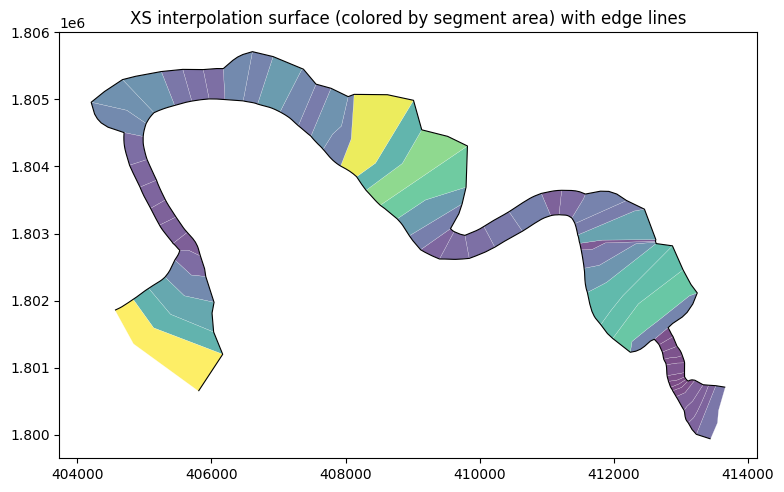

In [4]:
if HECRAS_AVAILABLE:
    result = RasGeometryCompute.generate_interpolation_surface(geom_hdf, ras_object=ras, overwrite=True)
    print(result)

surface = HdfXsec.get_xs_interpolation_surface(geom_hdf)
describe(surface, "interpolation surface (per XS segment)")
if not surface.empty:
    display(surface[["surface_id", "us_xs_id", "ds_xs_id", "area"]].head())
    fig, ax = plt.subplots(figsize=(9, 6))
    surface.plot(ax=ax, column="area", cmap="viridis", alpha=0.7, edgecolor="white", linewidth=0.2)
    edges.plot(ax=ax, color="black", linewidth=0.8)
    ax.set_title("XS interpolation surface (colored by segment area) with edge lines")
    ax.set_aspect("equal")
    plt.show()

## Generate river flow paths — with overwrite/backup safety

`generate_flow_paths()` runs *Create Flow Paths from XS Layout*. HEC-RAS keeps **no cache
hash** for flow paths, so any regeneration replaces them unconditionally. To protect
manually defined or optimized flow paths, this method **defaults to skip-if-exists**
(`overwrite=False`). Use `HdfXsec.get_river_flow_paths()` to check first; pass
`overwrite=True` to regenerate, and with `backup=True` (default) the existing flow paths
are exported to a dated `.geojson.bak` sidecar before being replaced.

In [5]:
if HECRAS_AVAILABLE:
    # First generation (none exist yet).
    print(RasGeometryCompute.generate_flow_paths(geom_hdf, ras_object=ras))

    # Calling again without overwrite is a no-op — manual edits are safe.
    print(RasGeometryCompute.generate_flow_paths(geom_hdf, ras_object=ras))

    # Force a regeneration; the existing flow paths are backed up first.
    forced = RasGeometryCompute.generate_flow_paths(geom_hdf, ras_object=ras,
                                                     overwrite=True, backup=True)
    print(forced)
    if forced.backup_path:
        print("  backup written:", forced.backup_path.name)

flow_paths = HdfXsec.get_river_flow_paths(geom_hdf)
describe(flow_paths, "flow paths")

GeometryLayerResult(SKIPPED, layer='River Flow Paths', time=0.0s)


GeometryLayerResult(SKIPPED, layer='River Flow Paths', time=0.0s)


2026-07-15 21:00:45 - pyogrio._io - INFO - Created 2 records


GeometryLayerResult(SUCCESS, layer='River Flow Paths', time=1.1s)
  backup written: Muncie.g01.flow_paths.20260715_210045.geojson.bak


  flow paths: rows=2 types=['LineString'] valid=True


## Validate geometry — which cross sections need attention

Overlapping cut lines, self-intersecting edge lines, irregular cross sections, and high
channel sinuosity can block edge-line and interpolation-surface generation.
`validate_geometry()` returns HEC-RAS's own per-feature diagnostics — severity, the
offending River/Reach/RS, and the message — so you know exactly which cut lines to fix.

In [6]:
if HECRAS_AVAILABLE:
    diagnostics = RasGeometryCompute.validate_geometry(geom_hdf, ras_object=ras)
    print(f"{len(diagnostics)} diagnostic(s); geometry valid (no ERROR): "
          f"{RasGeometryCompute.is_valid_geometry(geom_hdf, ras_object=ras)}")
    if not diagnostics.empty:
        display(diagnostics[["severity", "layer", "River", "Reach", "RS", "message"]])
else:
    print("HEC-RAS unavailable; skipping validation.")

4 diagnostic(s); geometry valid (no ERROR): False


,severity,layer,River,Reach,RS,message
0,ERROR,Cross Sections,White,Muncie,1980.776,XS Profile length is different than Polyline l...
1,ERROR,Cross Sections,White,Muncie,1980.776,Right Bank Station point is different than the...
2,ERROR,"Bank Lines, Flow Paths",NaN,NaN,NaN,Bankline intersected FlowPathLine
3,ERROR,"Bank Lines, Flow Paths",NaN,NaN,NaN,Bankline intersected FlowPathLine


## Run the whole pipeline at once

`compute_geometry()` is the in-process equivalent of RASMapper's *Compute Geometry*
(and of `RasProcess.compute_geometry()` on Linux). It generates edge lines, the
interpolation surface, bank lines, ineffective areas, blocked obstructions, and 2D
property tables in one call. **Flow paths are not part of this pipeline** — generate
those separately with `generate_flow_paths()`.

In [7]:
if HECRAS_AVAILABLE:
    fresh = extract_or_reuse("Muncie", "geom_completion_bundled")
    ras2 = RasPrj()
    init_ras_project(fresh, "6.6", ras_object=ras2)
    fresh_geom = find_geom_with_xs(fresh, ras2)
    result = RasGeometryCompute.compute_geometry(fresh_geom, ras_object=ras2, overwrite=True)
    print(result)
    print("  edge lines:", result.edge_lines_written)
    print("  interpolation surface:", result.interpolation_surface_written)
    print("  flow paths (expected False — not part of the pipeline):", result.flow_paths_written)
else:
    print("HEC-RAS unavailable; skipping compute_geometry.")

2026-07-15 21:00:51 - pyogrio._io - INFO - Created 2 records


GeometryCompleteResult(SUCCESS, edge_lines=True, interp_surface=True, flow_paths=False, time=2.5s)
  edge lines: True
  interpolation surface: True
  flow paths (expected False — not part of the pipeline): False


## Audit reach lengths (flow lengths) against the current cut lines

A 1D unsteady model requires LOB / channel / ROB **reach lengths** on every cross section;
HEC-RAS measures those along the flow paths, so they go stale when cut lines move.
`audit_reach_lengths()` copies the whole project (the original is never touched), recomputes
the reach lengths from the flow paths on the copy, and returns a per-XS before/after diff so
you can see which lengths drifted. By default it leaves existing (possibly hand-edited) flow
paths untouched and generates them only when absent.

cross sections audited: 61
reach-length values changed (> tolerance): 60
used existing flow paths: True


,River,Reach,RS,len_left_stored,len_left_recomputed,delta_left,len_right_stored,len_right_recomputed,delta_right
0,White,Muncie,15696.24,228.660004,229.000000,0.339996,167.839996,189.300003,21.460007
1,White,Muncie,15485.51,121.230003,124.599998,3.369995,103.790001,115.300003,11.510002
2,White,Muncie,15370.43,174.809998,180.699997,5.889999,117.820000,142.100006,24.280006
3,White,Muncie,15205.29,216.559998,227.399994,10.839996,159.110001,182.500000,23.389999
4,White,Muncie,15013.20,98.059998,100.000000,1.940002,84.000000,105.900002,21.900002
5,White,Muncie,14917.36,60.310001,60.200001,-0.110001,51.130001,54.400002,3.270000
6,White,Muncie,14856.24,81.169998,90.900002,9.730003,51.970001,54.799999,2.829998
7,White,Muncie,14787.40,88.660004,89.900002,1.239998,73.830002,78.900002,5.070000


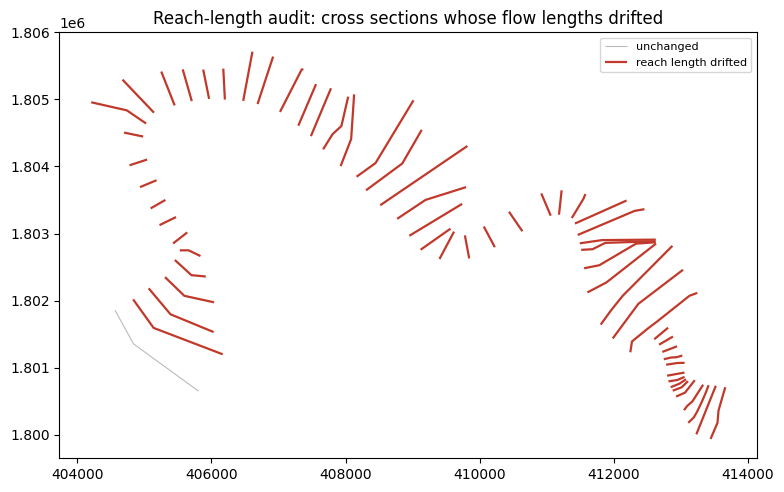


Checks passed: original geometry untouched; reach-length drift detected.


In [8]:
if HECRAS_AVAILABLE:
    import hashlib
    before_hash = hashlib.md5(geom_hdf.read_bytes()).hexdigest()

    audit = RasGeometryCompute.audit_reach_lengths(geom_hdf, ras_object=ras)
    print(f"cross sections audited: {len(audit)}")
    print(f"reach-length values changed (> tolerance): {audit.attrs['changed_count']}")
    print(f"used existing flow paths: {audit.attrs['used_existing_flow_paths']}")

    # The audit copies the whole project; the original geometry HDF is never modified.
    assert hashlib.md5(geom_hdf.read_bytes()).hexdigest() == before_hash, "audit modified the original!"
    assert audit.attrs["changed_count"] > 0          # stock Muncie authored lengths have drifted
    assert bool(audit["reach_end"].any())            # each reach's downstream terminus is flagged

    changed = audit[audit["changed"]]
    display(changed[["River", "Reach", "RS",
                     "len_left_stored", "len_left_recomputed", "delta_left",
                     "len_right_stored", "len_right_recomputed", "delta_right"]].head(8))

    # Map the cross sections whose reach lengths drifted.
    fig, ax = plt.subplots(figsize=(9, 6))
    audit[~audit["changed"]].plot(ax=ax, color="#bbbbbb", linewidth=0.8, label="unchanged")
    if not changed.empty:
        changed.plot(ax=ax, color="#c0392b", linewidth=1.6, label="reach length drifted")
    ax.set_title("Reach-length audit: cross sections whose flow lengths drifted")
    ax.set_aspect("equal")
    ax.legend(loc="best", fontsize=8)
    plt.show()

    print("\nChecks passed: original geometry untouched; reach-length drift detected.")
else:
    print("HEC-RAS unavailable; skipping reach-length audit.")

## Key takeaways

- **`RasGeometryCompute`** drives RASMapper's geometry completion in-process (pythonnet),
  Windows only. On Linux, use **`RasProcess.compute_geometry()`** (RasProcess.exe + Wine).
- Generate layers individually (`generate_edge_lines` / `generate_interpolation_surface`
  / `generate_flow_paths`) or all at once (`compute_geometry`). Flow paths are separate —
  `compute_geometry` does not create them.
- Read results with the pure-h5py `HdfXsec` readers (`get_river_edge_lines`,
  `get_xs_interpolation_surface`, `get_river_flow_paths`) — no HEC-RAS needed to read.
- **`generate_flow_paths()` never clobbers existing flow paths by default** (skip-if-exists);
  `overwrite=True` backs them up to a dated `.geojson.bak` first.
- **`audit_reach_lengths()`** copies the project, recomputes reach lengths from the flow
  paths, and reports which cross sections' LOB/channel/ROB lengths drifted — a QA step
  after editing cut lines (a 1D unsteady model needs current reach lengths).
- **`validate_geometry()`** surfaces HEC-RAS's per-cross-section problems so you can fix the
  offending cut lines; **`is_valid_geometry()`** is the boolean gate.